In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Simple EDA

        RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0     1
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0     1
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0     1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB
None
     

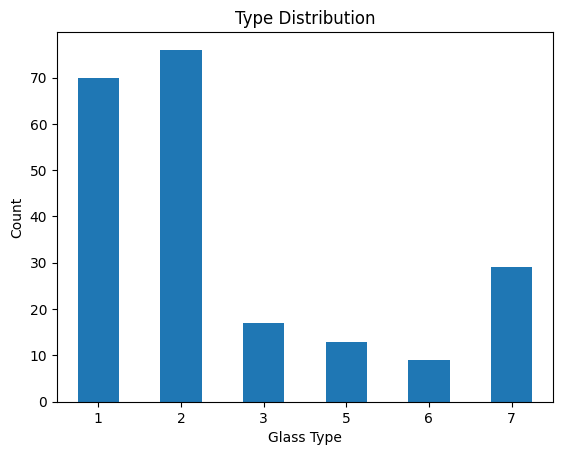

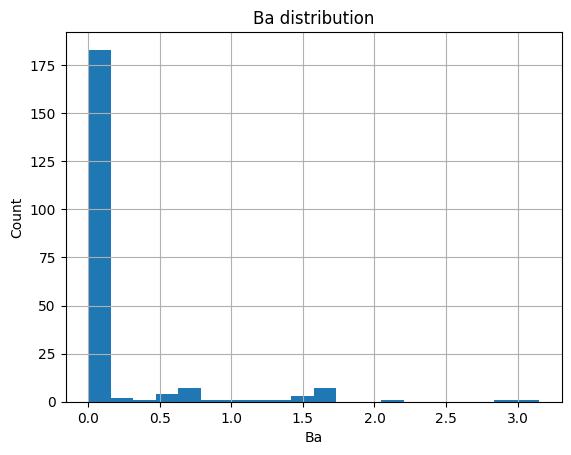

In [2]:
def load_data(path):
    df = pd.read_csv(path)
    return df

def inspect_df(df):
    print(df.head(5))
    print(df.info())
    print(df.describe())

def plot_type(df):
    df['Type'].value_counts().sort_index().plot(kind='bar')
    plt.xlabel('Glass Type')
    plt.ylabel('Count')
    plt.title('Type Distribution')
    plt.xticks(rotation=0)
    plt.show()

def plot_element(df, element):
    df[element].hist(bins=20)
    plt.xlabel(element)
    plt.ylabel('Count')
    plt.title(f'{element} distribution')
    plt.show()
    
df = load_data("../data/glass.csv")
inspect_df(df)
plot_type(df)
plot_element(df, 'Ba')

In [3]:
def split_data(df, test_size):
    y = df['Type']
    X = df.drop(columns=['Type'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = test_size, stratify=y)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = split_data(df, 0.2)
print(y_train.value_counts())

Type
2    61
1    56
7    23
3    14
5    10
6     7
Name: count, dtype: int64


# Logistic Regression Pipeline

In [4]:

def base_logi_model(X_train):
    """Build base model first no lda or smote"""
    column_names = list(X_train.columns)
    preprocessor = ColumnTransformer(transformers=[
        ('nums', StandardScaler(), column_names)
    ])
    pipeline = Pipeline(steps=[
        ('preprocess', preprocessor),
        # multinomial LogisticRegression (sklearn's default for 3+ classes):
        # trains 6 separate scoring equations simultaneously (one per Type),
        # each with 5 coefficients + 1 intercept. NOT 6 separate boundaries
        # you could draw — softmax converts the 6 raw scores per point into
        # 6 competing probabilities that sum to 1, highest wins
        ('model', LogisticRegression())
    ])
    return pipeline

def logi_smote(X_train):
    """model with SMOTE"""
    column_names = list(X_train.columns)
    preprocessor = ColumnTransformer(transformers=[
        ('nums', StandardScaler(), column_names)
    ])
    pipeline = ImbPipeline(steps=[
        # ImbPipeline required here, NOT plain Pipeline — SMOTE changes row
        # count (synthesizes new minority-class rows)
        ('preprocess', preprocessor),
        ('smote', SMOTE(random_state=42, k_neighbors =3)),
        ('model', LogisticRegression())
    ])
    return pipeline

def logi_lda(X_train):
    """model with lda"""
    column_names = list(X_train.columns)
    preprocessor = ColumnTransformer(transformers=[
        ('nums', StandardScaler(), column_names)
    ])
    pipeline = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('lda', LinearDiscriminantAnalysis()),
        ('model', LogisticRegression())
    ])
    return pipeline

def logi_smote_lda(X_train):
    """model with SMOTE and lda"""
    column_names = list(X_train.columns)
    preprocessor = ColumnTransformer(transformers=[
        ('nums', StandardScaler(), column_names)
    ])
    pipeline = ImbPipeline(steps=[
        ('preprocess', preprocessor),
        ('smote', SMOTE(random_state=42, k_neighbors=3)),
        # SMOTE before LDA: LDA calculates each class's mean/spread to find
        # its separating axis — feeding it balanced data (post-SMOTE) gives
        # more stable class statistics than the raw, imbalanced version would
        ('lda', LinearDiscriminantAnalysis()),
        ('model', LogisticRegression())
    ])
    return pipeline

def hyperparameter_tunning_lda(pipeline, X_train, y_train):
    """tunnning for lda only"""
    params_grid = {
        'lda__n_components':[1, 2, 3, 4, 5],
    } 
    grid_search = GridSearchCV(pipeline, params_grid, cv = 5, scoring = 'recall_macro') #optimze recall becuase not capturing the right type/class will be costly
    grid_search.fit(X_train, y_train)
    return grid_search.best_estimator_


def matrix_calculation(y_test, pred):
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred, average='macro')
    recall = recall_score(y_test, pred, average='macro')
    f1 = f1_score(y_test, pred, average='macro')
    matrix = confusion_matrix(y_test, pred)
    return accuracy, precision, recall, f1, matrix


# Base model first
base_pipeline = base_logi_model(X_train)
base_pipeline = base_pipeline.fit(X_train, y_train)
pred_1 = base_pipeline.predict(X_test)
accuracy_1, precision_1, recall_1, f1_1, matrix_1 = matrix_calculation(y_test, pred_1)
print(f"Base model:\nAccuracy: {accuracy_1}\nPrecision: {precision_1}\nRecall: {recall_1}\nF1: {f1_1}")
print("=" * 50)

# Base model + SMOTE
smote_pipeline = logi_smote(X_train)
smote_pipeline = smote_pipeline.fit(X_train, y_train)
pred_2 = smote_pipeline.predict(X_test)
accuracy_2, precision_2, recall_2, f1_2, matrix_2 = matrix_calculation(y_test, pred_2)
print(f"Base + SMOTE:\nAccuracy: {accuracy_2}\nPrecision: {precision_2}\nRecall: {recall_2}\nF1: {f1_2}")
print("=" * 50)

# Base model + LDA
lda_pipeline = logi_lda(X_train)
best_lda_pipeline = hyperparameter_tunning_lda(lda_pipeline, X_train, y_train)
pred_3 = best_lda_pipeline.predict(X_test)
accuracy_3, precision_3, recall_3, f1_3, matrix_3 = matrix_calculation(y_test, pred_3)
print(f"Base + LDA (n_components={best_lda_pipeline.named_steps['lda'].n_components}):\nAccuracy: {accuracy_3}\nPrecision: {precision_3}\nRecall: {recall_3}\nF1: {f1_3}")
print("=" * 50)

# Base model + SMOTE + LDA
all_pipeline = logi_smote_lda(X_train)
best_all_pipeline = hyperparameter_tunning_lda(all_pipeline, X_train, y_train)
pred_4 = best_all_pipeline.predict(X_test)
accuracy_4, precision_4, recall_4, f1_4, matrix_4 = matrix_calculation(y_test, pred_4)
print(f"Base + SMOTE + LDA (n_components={best_all_pipeline.named_steps['lda'].n_components}):\nAccuracy: {accuracy_4}\nPrecision: {precision_4}\nRecall: {recall_4}\nF1: {f1_4}")
print("=" * 50)

recall_scores = {
    'base': recall_1,
    'smote': recall_2,
    'lda': recall_3,
    'smote_lda': recall_4
}

best_name = max(recall_scores, key=lambda name: recall_scores[name])
print(f"Best model: {best_name} (recall={recall_scores[best_name]})")

Base model:
Accuracy: 0.6976744186046512
Precision: 0.6296296296296297
Recall: 0.6753968253968253
F1: 0.646329365079365


c:\Users\Edward\Desktop\python\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Base + SMOTE:
Accuracy: 0.6976744186046512
Precision: 0.7254273504273504
Recall: 0.8079365079365081
F1: 0.7269262675059777


c:\Users\Edward\Desktop\python\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Base + LDA (n_components=4):
Accuracy: 0.5813953488372093
Precision: 0.5564102564102564
Recall: 0.6174603174603174
F1: 0.5780651340996169
Base + SMOTE + LDA (n_components=5):
Accuracy: 0.627906976744186
Precision: 0.6162037037037037
Recall: 0.7730158730158729
F1: 0.6487558817993601
Best model: smote (recall=0.8079365079365081)


# Random Forest Pipeline

In [7]:
def base_rf_model():
    """Random Forest base model"""
    pipeline = Pipeline(steps=[
        ('model', RandomForestClassifier(random_state=42))
    ])
    return pipeline

def rf_smote():
    """base model + smote"""
    pipeline = ImbPipeline(steps=[
        ('smote', SMOTE(random_state=42, k_neighbors=3)),
        ('model', RandomForestClassifier(random_state=42))
    ])
    return pipeline

def rf_lda(X_train):
    """base model + lda"""
    column_name = list(X_train.columns)
    preprocessor = ColumnTransformer(transformers=[
        ('nums', StandardScaler(), column_name)
    ])
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('lda', LinearDiscriminantAnalysis()),
        ('model', RandomForestClassifier(random_state=42))
    ])
    return pipeline

def rf_smote_lda(X_train):
    """base model + lda"""
    column_name = list(X_train.columns)
    preprocessor = ColumnTransformer(transformers=[
        ('nums', StandardScaler(), column_name)
    ])
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42, k_neighbors=3)),
        ('lda', LinearDiscriminantAnalysis()),
        ('model', RandomForestClassifier(random_state=42))
    ])
    return pipeline

def hyperparameter_tunning_tree(pipeline, X_train, y_train):
    """hyperparameter tunning for rf only"""
    params_grid = {
        'model__n_estimators': [50, 100, 500],
        'model__max_depth' : [5, 7, 9],
        'model__min_samples_split' : [2, 4, 6]
    }
    grid_search = GridSearchCV(pipeline, params_grid, cv = 5, scoring='recall_macro')
    grid_search.fit(X_train, y_train)
    return grid_search.best_estimator_

def hyperparameter_tunning_tree_lda(pipeline, X_train, y_train):
    """hyperparameter tunning for rf with lda"""
    params_grid = {
        'lda__n_components' : [1, 2, 3, 4, 5],
        'model__n_estimators': [50, 100, 500],
        'model__max_depth' : [5, 7, 9],
        'model__min_samples_split' : [2, 4, 6]
    }
    grid_search = GridSearchCV(pipeline, params_grid, cv = 5, scoring='recall_macro')
    grid_search.fit(X_train, y_train)
    return grid_search.best_estimator_

# Base rf model
base_rf = base_rf_model()
best_base_rf = hyperparameter_tunning_tree(base_rf, X_train, y_train)
pred_rf_1 = best_base_rf.predict(X_test)
accuracy_rf_1, precision_rf_1, recall_rf_1, f1_rf_1, matrix_rf_1 = matrix_calculation(y_test, pred_rf_1)

# Base rf + SMOTE 
smote_rf = rf_smote()
best_smote_rf = hyperparameter_tunning_tree(smote_rf, X_train, y_train)
pred_rf_2 = best_smote_rf.predict(X_test)
accuracy_rf_2, precision_rf_2, recall_rf_2, f1_rf_2, matrix_rf_2 = matrix_calculation(y_test, pred_rf_2)

# Base rf + lda
lda_rf = rf_lda(X_train)
best_lda_rf = hyperparameter_tunning_tree_lda(lda_rf, X_train, y_train)
pred_rf_3 = best_lda_rf.predict(X_test)
accuracy_rf_3, precision_rf_3, recall_rf_3, f1_rf_3, matrix_rf_3 = matrix_calculation(y_test, pred_rf_3)

# Base rf + SMOTE + lda
smote_lda_rf = rf_smote_lda(X_train)
best_smote_lda_rf = hyperparameter_tunning_tree_lda(smote_lda_rf, X_train, y_train)
pred_rf_4 = best_smote_lda_rf.predict(X_test)
accuracy_rf_4, precision_rf_4, recall_rf_4, f1_rf_4, matrix_rf_4, = matrix_calculation(y_test, pred_rf_4)

print(f"Base RF:\nAccuracy: {accuracy_rf_1}\nPrecision: {precision_rf_1}\nRecall: {recall_rf_1}\nF1: {f1_rf_1}")
print(f"Best params: {best_base_rf.named_steps['model'].get_params()}")
print("=" * 50)

print(f"RF + SMOTE:\nAccuracy: {accuracy_rf_2}\nPrecision: {precision_rf_2}\nRecall: {recall_rf_2}\nF1: {f1_rf_2}")
print(f"Best params: {best_smote_rf.named_steps['model'].get_params()}")
print("=" * 50)

print(f"RF + LDA:\nAccuracy: {accuracy_rf_3}\nPrecision: {precision_rf_3}\nRecall: {recall_rf_3}\nF1: {f1_rf_3}")
print(f"Best params: {best_lda_rf.named_steps['model'].get_params()}, n_components={best_lda_rf.named_steps['lda'].n_components}")
print("=" * 50)

print(f"RF + SMOTE + LDA:\nAccuracy: {accuracy_rf_4}\nPrecision: {precision_rf_4}\nRecall: {recall_rf_4}\nF1: {f1_rf_4}")
print(f"Best params: {best_smote_lda_rf.named_steps['model'].get_params()}, n_components={best_smote_lda_rf.named_steps['lda'].n_components}")
print("=" * 50)

recall_scores_rf = {
    'base': recall_rf_1,
    'smote': recall_rf_2,
    'lda': recall_rf_3,
    'smote_lda': recall_rf_4
}

best_name_rf = max(recall_scores_rf, key=lambda name: recall_scores_rf[name])
print(f"Best RF model: {best_name_rf} (recall={recall_scores_rf[best_name_rf]})")




c:\Users\Edward\Desktop\python\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Base RF:
Accuracy: 0.7441860465116279
Precision: 0.7202380952380952
Recall: 0.6698412698412698
F1: 0.6732621784345922
Best params: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 9, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 4, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
RF + SMOTE:
Accuracy: 0.7906976744186046
Precision: 0.8134920634920636
Recall: 0.6928571428571427
F1: 0.7038040503557745
Best params: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 9, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 50, 'n_jo

# XGBoost Pipeline

In [ ]:
from xgboost import XGBClassifier

def base_xgb_model():
    """XGBoost base model"""
    pipeline = Pipeline(steps=[
        # no scaling/preprocessing needed - tree splits are scale-invariant
        ('model', XGBClassifier(random_state=42))
    ])
    return pipeline

def hyperparameter_tunning_xgb(pipeline, X_train, y_train):
    """hyperparameter tunning for xgboost only"""
    params_grid = {
        'model__n_estimators': [50, 100, 500],
        'model__max_depth': [3, 5, 7],
        'model__learning_rate': [0.01, 0.1, 0.3]
    }
    grid_search = GridSearchCV(pipeline, params_grid, cv=5, scoring='recall_macro')
    grid_search.fit(X_train, y_train)
    return grid_search.best_estimator_

# Base xgb model
# XGBClassifier handles the non-contiguous Type labels (1,2,3,5,6,7) internally
# via its own label encoding - no manual LabelEncoder needed
base_xgb = base_xgb_model()
best_base_xgb = hyperparameter_tunning_xgb(base_xgb, X_train, y_train)
pred_xgb_1 = best_base_xgb.predict(X_test)
accuracy_xgb_1, precision_xgb_1, recall_xgb_1, f1_xgb_1, matrix_xgb_1 = matrix_calculation(y_test, pred_xgb_1)

print(f"Base XGBoost:\nAccuracy: {accuracy_xgb_1}\nPrecision: {precision_xgb_1}\nRecall: {recall_xgb_1}\nF1: {f1_xgb_1}")
print(f"Best params: {best_base_xgb.named_steps['model'].get_params()}")
print("=" * 50)